# SussexBudgetProductions

In [1]:
import sys

print("My python version:")
print(sys.version)

My python version:
3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]


In [2]:
# Import necessary libraries 
import numpy as np 
import pandas as pd 

# Import matplotlib for plotting 
import matplotlib.pyplot as plt 

# Import seaborn for advanced visualizations 
import seaborn as sns 

# Import t-test from scipy for hypothesis testing 
from scipy.stats import ttest_ind

## Data Collection

This function, `read_data`, takes a filename (`fname`) as input and returns a DataFrame by reading the CSV file.

In [3]:
# Reads a CSV file into a DataFrame
def read_data(fname): 
    return pd.read_csv(fname)

In [4]:
# Specify the path to the CSV file
fname = r"C:\Users\askar\OneDrive\ASKAR\Data Science\Sussex\Data Science Research Methods\Report\movie_metadata.csv"

# Read the CSV file
imdb_movie_data_df = read_data(fname)

## Dataset Overview and Summary Statistics

In [5]:
print("A preview of the data is shown below")

display(imdb_movie_data_df.head(5))

A preview of the data is shown below


,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


### Overview Insights

In [6]:
print("Dataset Overview: Displaying the structure, data types, and non-null values of each column.\n")

## Display the DataFrame's structure
print(imdb_movie_data_df.info())

Dataset Overview: Displaying the structure, data types, and non-null values of each column.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_u

- **Total Entries**: The dataset contains 5043 movie records.
- **Missing Values**: Some columns have missing values:
- **Key Features**: 
  - `genres`: crucial for genre-based analysis.
  - `gross`, `budget`: Key for calculating profitability.
  - `imdb_score`: A valuable metric for movie ratings.
  
This summary also gives an overview of the dataset’s structure and identifies areas that may need data cleaning.


### Key Summary Statistics

In [7]:
# Display summary statistics for numerical columns
display(imdb_movie_data_df.describe())

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,4993.000000,5028.000000,4939.000000,5020.000000,5036.000000,4.159000e+03,5.043000e+03,5043.000000,5030.000000,5022.000000,4.551000e+03,4935.000000,5030.000000,5043.000000,4714.000000,5043.000000
mean,140.194272,107.201074,686.509212,645.009761,6560.047061,4.846841e+07,8.366816e+04,9699.063851,1.371173,272.770808,3.975262e+07,2002.470517,1651.754473,6.442138,2.220403,7525.964505
std,121.601675,25.197441,2813.328607,1665.041728,15020.759120,6.845299e+07,1.384853e+05,18163.799124,2.013576,377.982886,2.061149e+08,12.474599,4042.438863,1.125116,1.385113,19320.445110
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000
25%,50.000000,93.000000,7.000000,133.000000,614.000000,5.340988e+06,8.593500e+03,1411.000000,0.000000,65.000000,6.000000e+06,1999.000000,281.000000,5.800000,1.850000,0.000000
50%,110.000000,103.000000,49.000000,371.500000,988.000000,2.551750e+07,3.435900e+04,3090.000000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,166.000000
75%,195.000000,118.000000,194.500000,636.000000,11000.000000,6.230944e+07,9.630900e+04,13756.500000,2.000000,326.000000,4.500000e+07,2011.000000,918.000000,7.200000,2.350000,3000.000000
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.000000


- **Actor Facebook Likes**: 
  - Actor 1: Avg 6,560, max 640,000.
- **Gross Revenue**: Avg £48.5M, max £760M.
- **IMDB Rating**: Avg 6.44, range 1.6 to 9.5.
- **Budget**: Avg £39.7M, max £1.22B.
- **Movie Release year**: min 1916, max 2016

### Categorical Data Insights

In [8]:
# Display summary statistics for categorical columns
display(imdb_movie_data_df.describe(include = [object]))

,color,director_name,actor_2_name,genres,actor_1_name,movie_title,actor_3_name,plot_keywords,movie_imdb_link,language,country,content_rating
count,5024,4939,5030,5043,5036,5043,5020,4890,5043,5029,5038,4740
unique,2,2398,3032,914,2097,4917,3521,4760,4919,46,65,18
top,Color,Steven Spielberg,Morgan Freeman,Drama,Robert De Niro,Ben-Hur,John Heard,based on novel,http://www.imdb.com/title/tt0232500/?ref_=fn_t...,English,USA,R
freq,4815,26,20,236,49,3,8,4,3,4704,3807,2118


- **Director Name**: Steven Spielberg being the most frequent (26 movies).
- **Actor Name**: 
  - Actor 1: 5036 unique actors, with Robert De Niro being the most frequent (49 movies).
- **Genres**: "Drama" being the most common (236 movies).

## Data Wrangling and Cleaning

### 1) Dropping Unnecessary Columns

In this step, we remove columns from the dataset that are not needed for analysis to simplify the DataFrame and focus on more meaningful features.


In [9]:
# Columns to drop from the DataFrame
columns_to_drop = ['color', 'movie_imdb_link', 'aspect_ratio', 'facenumber_in_poster', 'plot_keywords', 'duration',
                   'director_facebook_likes', 'actor_2_name', 'actor_3_name', 'actor_3_facebook_likes', 'num_critic_for_reviews',
                   'actor_2_facebook_likes', 'movie_facebook_likes', 'cast_total_facebook_likes', 'language', 'country', 
                   'content_rating']

# Drop the specified columns
imdb_movie_data_df.drop(columns = columns_to_drop, inplace = True)

print(f'Columns remaining in the dataset after dropping unnecessary ones:\n\n {imdb_movie_data_df.columns}')

Columns remaining in the dataset after dropping unnecessary ones:

 Index(['director_name', 'actor_1_facebook_likes', 'gross', 'genres',
       'actor_1_name', 'movie_title', 'num_voted_users',
       'num_user_for_reviews', 'budget', 'title_year', 'imdb_score'],
      dtype='object')


### 2) Renaming Columns

In this section, we rename some columns to make them more descriptive and easier to understand.

In [10]:
# Columns to be renamed
new_column_names = {'gross': 'gross_revenue',
                    'actor_1_name': 'actor_name',
                    'title_year': 'release_year',
                    'actor_1_facebook_likes': 'actor_facebook_likes',
                    'num_voted_users': 'user_votes_count',
                    'num_user_for_reviews': 'user_reviews_count',
                    'imdb_score': 'imdb_rating'}

# Rename columns
imdb_movie_data_df.rename(columns = new_column_names, inplace = True)

print(f'Column names after modification:\n\n{imdb_movie_data_df.columns}')

Column names after modification:

Index(['director_name', 'actor_facebook_likes', 'gross_revenue', 'genres',
       'actor_name', 'movie_title', 'user_votes_count', 'user_reviews_count',
       'budget', 'release_year', 'imdb_rating'],
      dtype='object')


### 3) Removing Rows with Null Values

Next, we will identify rows that have missing values in any of the specified critical columns and drop them from the dataset.

In [11]:
# List of columns to check for missing values
critical_columns = ['director_name', 'gross_revenue', 'genres', 'actor_name', 'actor_facebook_likes', 'release_year',
                    'user_votes_count', 'user_reviews_count', 'budget', 'imdb_rating']

In [12]:
# # Identify rows with null values in the specified columns
rows_with_missing_values = imdb_movie_data_df[imdb_movie_data_df[critical_columns].isnull().any(axis = 1)].index

# Drop rows with null values in the specified columns
imdb_movie_data_df.dropna(subset = critical_columns, inplace = True)
imdb_movie_data_df.reset_index(drop = True,inplace = True)

print(f'A total of {len(rows_with_missing_values.tolist())} in critical columns have been removed.\n')

A total of 1155 in critical columns have been removed.



### 4) Handling Duplicate Rows
This step involves identifying duplicate rows in the dataset. Duplicate rows can skew the analysis

In [13]:
# Finding the total number of duplicate rows
duplicate_rows = imdb_movie_data_df.duplicated().sum()

# number of duplicate rows
print(f'There are {duplicate_rows} duplicate rows in the dataset')

There are 35 duplicate rows in the dataset


In [14]:
# Removing duplicate rows based on selected columns and keeping the last occurrence
imdb_movie_data_df.drop_duplicates(subset = critical_columns, keep = 'last', inplace = True)

# Print the number of duplicate rows

print(f"Duplicate rows have been dropped.\n")

Duplicate rows have been dropped.



## Feature Creation
### 1) Genre Classification
This code assigns new genre labels to the movies in the dataset based on whether the genre contains **"Romance" or "Horror"**. If neither genre is present, it classifies the movie as "Other."

In [15]:
# Assign new genre labels based on existing genres
imdb_movie_data_df['new_genres'] = imdb_movie_data_df['genres'].apply(lambda x: 'Romance' if 'Romance' in x else ('Horror' if 'Horror' in x else 'Other'))

print("Genre distribution after categorizing into Romance, Horror, and Other:\n")
print(imdb_movie_data_df['new_genres'].value_counts())

Genre distribution after categorizing into Romance, Horror, and Other:

new_genres
Other      2594
Romance     879
Horror      380
Name: count, dtype: int64


### 2) Profit-to-Budget Ratio
In this step, we are calculating the profit-to-budget ratio for each movie. 


**Profit-to-Budget Ratio = (Gross Revenue − Budget) / Budget**
 
This metric helps assess how much profit a movie generated for every unit of budget spent. A higher ratio indicates a more profitable movie relative to its budget.

In [16]:
# Assign profit-to-budget ratio
imdb_movie_data_df['profit_to_budget_ratio'] = (imdb_movie_data_df['gross_revenue'] - imdb_movie_data_df['budget']) / imdb_movie_data_df['budget']


In [17]:
# Displaying the information of the cleaned dataset
print("Sample data information after wrangling and cleaning:")
print(imdb_movie_data_df.info())

Sample data information after wrangling and cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 3853 entries, 0 to 3887
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   director_name           3853 non-null   object 
 1   actor_facebook_likes    3853 non-null   float64
 2   gross_revenue           3853 non-null   float64
 3   genres                  3853 non-null   object 
 4   actor_name              3853 non-null   object 
 5   movie_title             3853 non-null   object 
 6   user_votes_count        3853 non-null   int64  
 7   user_reviews_count      3853 non-null   float64
 8   budget                  3853 non-null   float64
 9   release_year            3853 non-null   float64
 10  imdb_rating             3853 non-null   float64
 11  new_genres              3853 non-null   object 
 12  profit_to_budget_ratio  3853 non-null   float64
dtypes: float64(7), int64(1), object(5)
memory us

## Data Filtering

### 1) Filtering based on User Reviews Count

Identifying the overall trend and the spread of review counts.

count    3853.000000
mean      326.687776
std       407.941808
min         1.000000
25%       102.000000
50%       203.000000
75%       391.000000
max      5060.000000
Name: user_reviews_count, dtype: float64

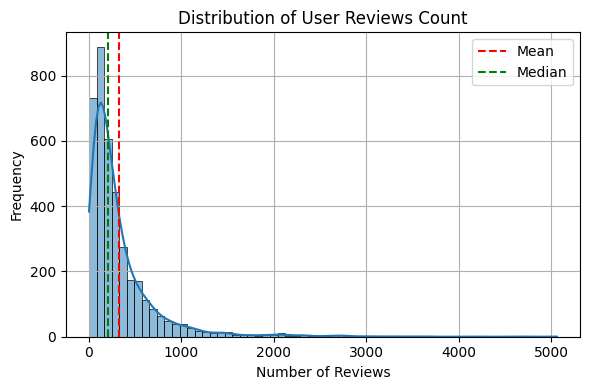

count    3853.000000
mean      326.687776
std       407.941808
min         1.000000
25%       102.000000
50%       203.000000
75%       391.000000
max      5060.000000
Name: user_reviews_count, dtype: float64

In [41]:
# Summary statistics of 'user_reviews_count'
display(imdb_movie_data_df['user_reviews_count'].describe())

# Calculate mean and median for user reviews
user_mean = imdb_movie_data_df['user_reviews_count'].mean()
user_median = imdb_movie_data_df['user_reviews_count'].median()

# Number of bins for the histogram
num_bins = int(np.sqrt(len(imdb_movie_data_df)))

# Plotting the distribution of user reviews
plt.figure(figsize = (6, 4))
sns.histplot(imdb_movie_data_df['user_reviews_count'], bins = num_bins, kde = True)

# Add mean and median lines
plt.axvline(user_mean, color = 'red', linestyle = 'dashed', label = 'Mean')
plt.axvline(user_median, color = 'green', linestyle = 'dashed', label = 'Median')

# Plot title and labels
plt.title('Distribution of User Reviews Count')
plt.xlabel('Number of Reviews')
plt.ylabel('Frequency')
plt.grid(True)
plt.legend()

# Adjust layout for better view
plt.tight_layout()
plt.show()

display(imdb_movie_data_df['user_reviews_count'].describe())

In this step, we are filtering the dataset to **include only the movies with a user reviews count greater than or equal to 400 (the 25th percentile value)**. We are considering movies with reviews above the threshold value as relevant for further analysis.

In [19]:
# Threshold for filtering based on user reviews count
user_threshold = 400  # Considering the 25th percentile value

# Filter the dataset to include movies with reviews count greater than or equal to 400
cleaned_movie_df = imdb_movie_data_df[imdb_movie_data_df['user_reviews_count'] >= user_threshold]

### 2) Filtering Movies Based on Release Year

In this step, we filter the dataset to include only movies released after the year 1995. By applying this filter, we aim to analyze trends and patterns in more recent movies, excluding older films from the dataset. 

This filter helps in focusing on movies that are more recent and potentially relevant for current analysis or modeling tasks.


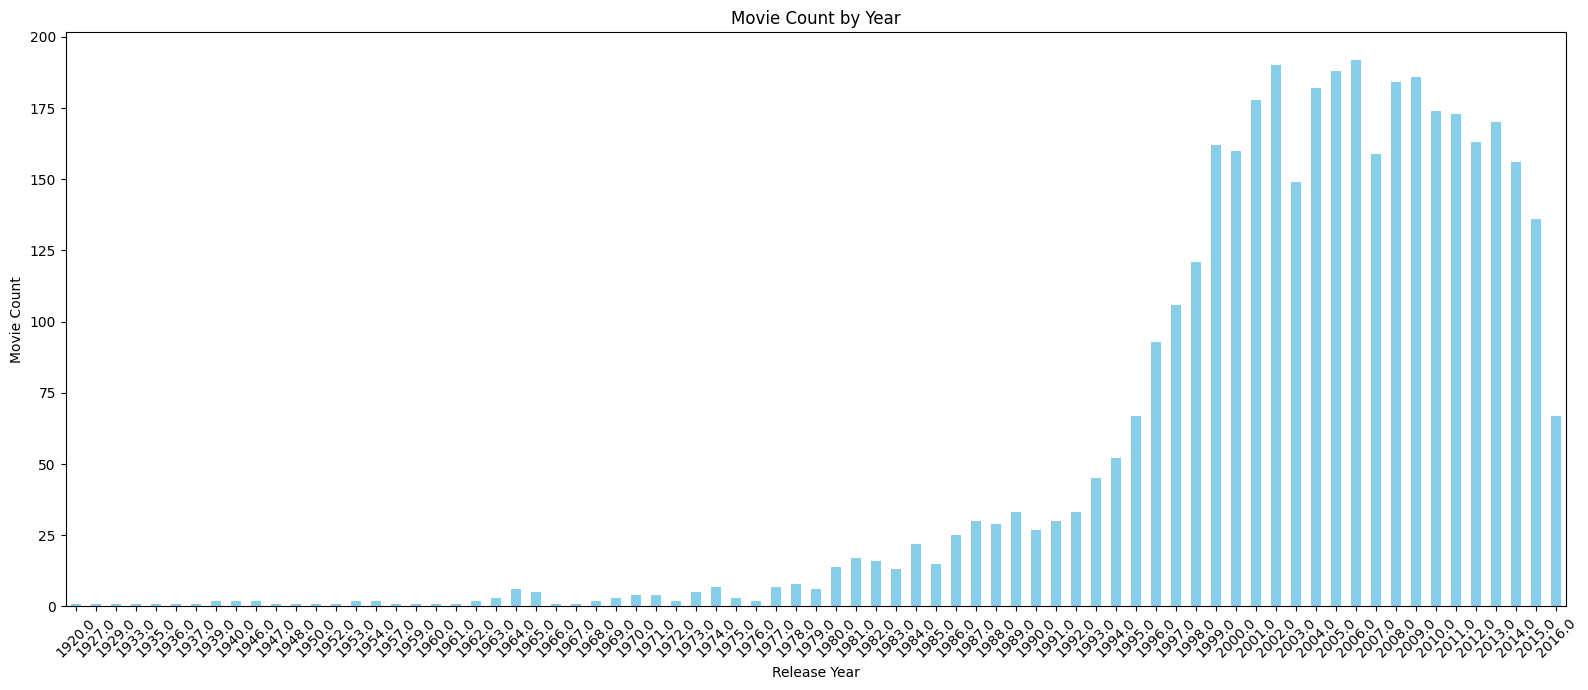

In [45]:
# Number of movies for each release year
movie_count_per_year = imdb_movie_data_df['release_year'].value_counts().sort_index()

# Plot the movie count by year
plt.figure(figsize = (16, 7))
movie_count_per_year.plot(kind = 'bar', color = 'skyblue')

# Plot title and labels
plt.title('Movie Count by Year')
plt.xlabel('Release Year')
plt.xticks(rotation = 45)
plt.ylabel('Movie Count')


# Adjust layout for better view
plt.tight_layout()
plt.show()

Filtering the data from 1996 allows to focus on a more relevant, modern, and evolving landscape in the film industry.

In [21]:
# Filter movies released after 1995
cleaned_movie_df = cleaned_movie_df[cleaned_movie_df['release_year'] > 1995]

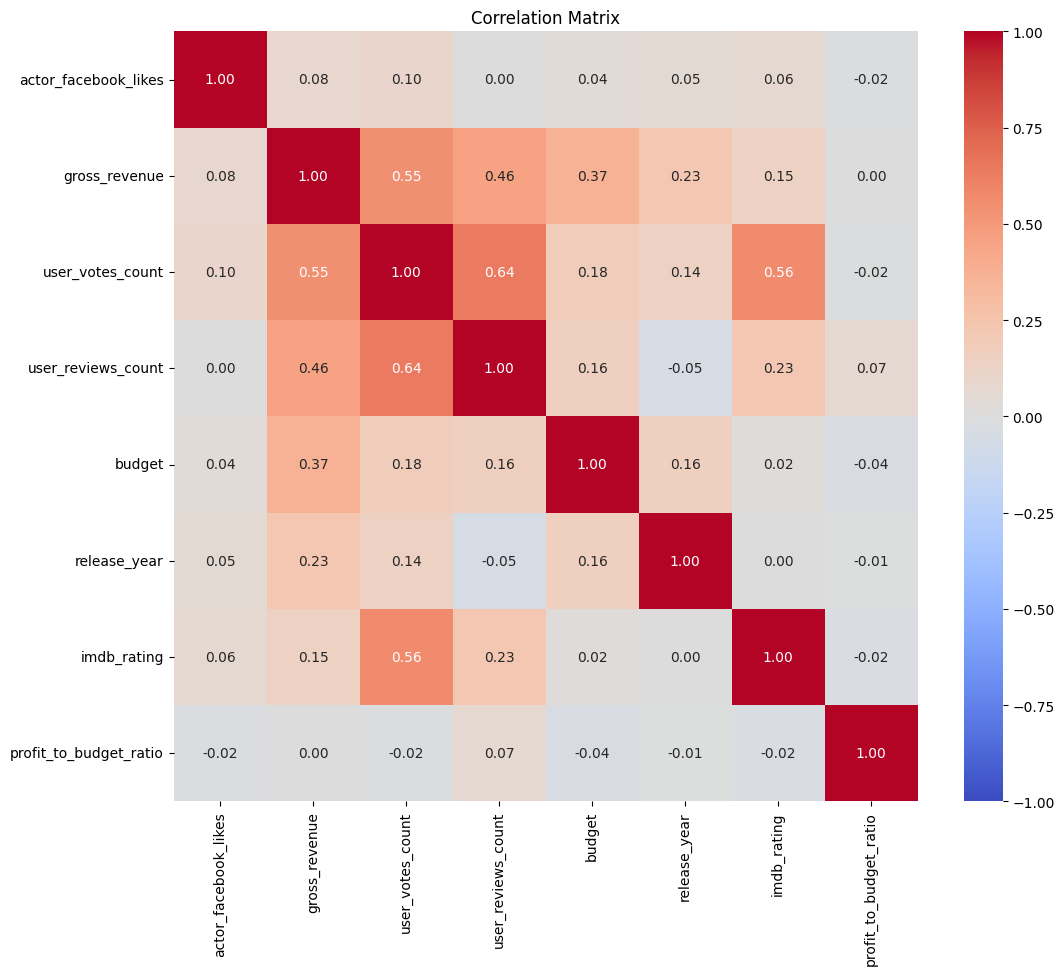

In [27]:
numeric_df = cleaned_movie_df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

# Display the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

In [231]:
cleaned_movie_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 834 entries, 0 to 3864
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   director_name           834 non-null    object 
 1   actor_facebook_likes    834 non-null    float64
 2   gross_revenue           834 non-null    float64
 3   genres                  834 non-null    object 
 4   actor_name              834 non-null    object 
 5   movie_title             834 non-null    object 
 6   user_votes_count        834 non-null    int64  
 7   user_reviews_count      834 non-null    float64
 8   budget                  834 non-null    float64
 9   release_year            834 non-null    float64
 10  imdb_rating             834 non-null    float64
 11  new_genres              834 non-null    object 
 12  profit_to_budget_ratio  834 non-null    float64
dtypes: float64(7), int64(1), object(5)
memory usage: 91.2+ KB


Now the data looks good but the sample length has got reduced significantly

### 3) Filtering Romance and Horror Movies
In this section, we are filtering the DataFrame to create separate subsets for **Romance** and **Horror** movies based on the `new_genres` column.

In [47]:
# Filter the cleaned DataFrame for movies in the Romance genre
df_romance = cleaned_movie_df[cleaned_movie_df['new_genres'] == 'Romance']

# Filter the cleaned DataFrame for movies in the Horror genre
df_horror = cleaned_movie_df[cleaned_movie_df['new_genres'] == 'Horror']

### Distribution of IMDb Ratings for Romance and Horror Genres
This plot visualizes the distribution of IMDb ratings for movies in the Romance and Horror genres and show how the ratings are spread out for each genre. 

The blue bars represent Romance movies, while the red bars represent Horror movies. This comparison helps us understand the rating patterns across both genres.


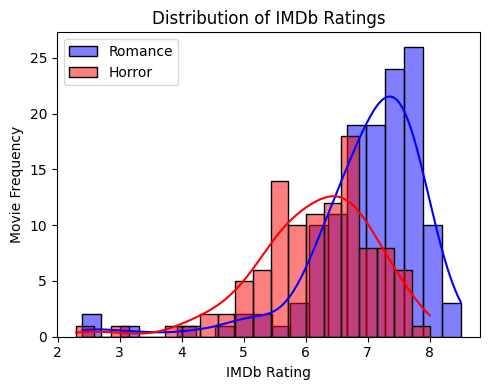

In [54]:
# Plot histogram for IMDb ratings for Romance and Horror
plt.figure(figsize=(5, 4))

sns.histplot(df_romance['imdb_rating'], kde = True, bins = 20, color = 'blue', label = 'Romance')
sns.histplot(df_horror['imdb_rating'], kde = True, bins = 20, color = 'red', label = 'Horror')

# Plot title and labels
plt.title('Distribution of IMDb Ratings')
plt.xlabel('IMDb Rating')
plt.ylabel('Movie Frequency')
plt.legend()

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

## Further analysis

### Top 5 Movies by IMDb Rating
This code snippet analyzes movie data to identify the top 5 highest-rated movies based on their IMDb ratings. A horizontal bar chart is then generated to visually represent this ranking.

Top 5 Movies by IMDb Rating (Average Rating: 8.86):


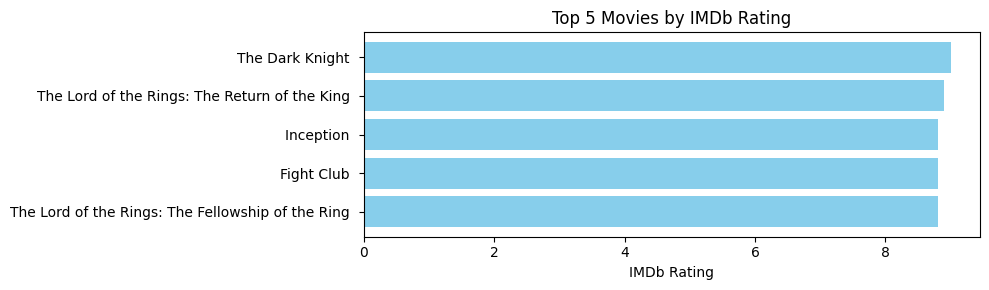

In [234]:
top_5_movies = cleaned_movie_df.sort_values(by = 'imdb_rating', ascending = False).head(5)

average_rating = top_5_movies['imdb_rating'].mean()
print(f"Top 5 Movies by IMDb Rating (Average Rating: {average_rating:.2f}):")


# Sorting movies by IMDb rating in descending order for the plot
sorted_top_5_movies = top_5_movies.sort_values(by = 'imdb_rating', ascending = True)

# Plotting the top 5 movies by IMDb rating
plt.figure(figsize = (10, 3))
plt.barh(sorted_top_5_movies['movie_title'], sorted_top_5_movies['imdb_rating'], color ='skyblue')

# Plot title and labels
plt.xlabel('IMDb Rating')
plt.title('Top 5 Movies by IMDb Rating')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


In [235]:
display(sorted_top_5_movies[['movie_title', 'imdb_rating']].tail(1))

,movie_title,imdb_rating
64,The Dark Knight,9.0


**Dark  knight** is the top movie with **9** imdb rating.

### Top 5  Movie Genres by IMDb rating
This code snippet analyzes movie data to identify the top 5 genres based on their IMDb ratings. A horizontal bar chart is then generated to visually represent this ranking.

Top 5 Movies by IMDb Rating (Average Rating: 8.86):


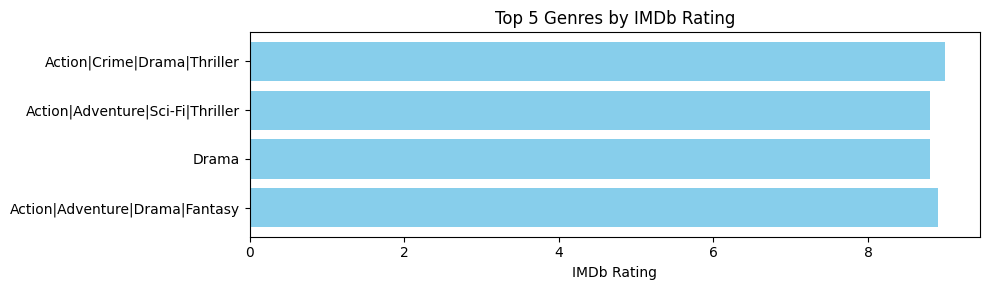

In [236]:
# Sorting the top 5 genres by IMDb rating in descending order
top_5_genres = cleaned_movie_df.sort_values(by = 'imdb_rating', ascending = False).head(5)

# average rating
average_rating = top_5_genres['imdb_rating'].mean()
print(f"Top 5 Movies by IMDb Rating (Average Rating: {average_rating:.2f}):")

# Plotting the top 5 genres by IMDb rating
sorted_top_5_genres = top_5_genres.sort_values(by = 'imdb_rating', ascending = True)

# Plotting the top 5 movies by IMDb rating
plt.figure(figsize = (10, 3))
plt.barh(sorted_top_5_genres['genres'], sorted_top_5_genres['imdb_rating'], color ='skyblue')

# Plot title and labels
plt.xlabel('IMDb Rating')
plt.title('Top 5 Genres by IMDb Rating')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

According to the graph and categorical summary insights, **Drama genre** is best to consider.

## Hypothesis Testing

In [237]:
# Set the significance level (alpha)
alpha = 0.05  # 5% significance level

### T-test for Profit-to-Budget Ratio between Romance and Horror Movies

This statistical test compares the profit-to-budget ratio between Romance and Horror movies. The t-test assesses whether the difference in means is statistically significant at a given alpha level. The result will help determine if the two genres have significantly different profit-to-budget ratios.

**Null Hypothesis (H0):** The mean gross profit ratio of Romance movies is equal to that of Horror movies.

**Alternative Hypothesis (H1):** The mean gross profit ratio of Romance movies is different from that of Horror movies.

In [238]:
#prepare data
data1_profit_ratio = df_romance['profit_to_budget_ratio']
data2_profit_ratio = df_horror['profit_to_budget_ratio']

# Perform t-test to compare the means of the profit-to-budget ratios
t_stat_profit_ratio, p_value_profit_ratio = ttest_ind(data1_profit_ratio, data2_profit_ratio, equal_var = False)

# Compare p-value with the significance level (alpha) to draw conclusions
if p_value_profit_ratio < alpha:
    print(f"Reject the null hypothesis at the {alpha*100}% significance level")
else:
    print(f"Fail to reject the null hypothesis at the {alpha*100}% significance level")
    
    
print(f"\nT-test for Profit to Budget Ratio:\nT-statistic = {t_stat_profit_ratio:.2f}, P-value = {p_value_profit_ratio:.4f}")

Fail to reject the null hypothesis at the 5.0% significance level

T-test for Profit to Budget Ratio:
T-statistic = -1.28, P-value = 0.2050


Surprisingly **no Significant difference** in the average Profit to Budget Ratio between Romance and Horror.

So we cannot make decision based on it.

### T-test for IMDb Ratings between Romance and Horror Movies

This statistical test compares the IMDb ratings between Romance and Horror movies. It evaluates whether the difference in mean IMDb ratings is statistically significant at a given alpha level. The result helps to understand if the two genres have significantly different average ratings.

**Null Hypothesis (H0):** The mean IMDb rating of Romance movies is equal to that of Horror movies.

**Alternative Hypothesis (H1):** The mean IMDb rating of Romance movies is different from that of Horror movies.

In [239]:
#prepare data
data1_imdb = df_romance['imdb_rating'].dropna()
data2_imdb = df_horror['imdb_rating'].dropna()

# Perform t-test to compare the means of IMDb ratings
t_stat_imdb, p_value_imdb = ttest_ind(data1_imdb, data2_imdb, equal_var = False)

# Compare p-value with the significance level (alpha) to draw conclusions
if p_value_imdb < alpha:
    print(f"Reject the null hypothesis at the {alpha*100}% significance level")
else:
    print(f"Fail to reject the null hypothesis at the {alpha*100}% significance level")
    
    
print(f"\nT-test for IMDb Rating:\nT-statistic = {t_stat_imdb:.2f}, P-value = {p_value_imdb:.4f}")

Reject the null hypothesis at the 5.0% significance level

T-test for IMDb Rating:
T-statistic = 6.42, P-value = 0.0000


**Statistically significant difference**

strongly suggests that one genre has higher average ratings than the other.

## Genre Comparison: Romance vs. Horror Based on IMDb Rating

In this section, we compare the average IMDb ratings between Romance and Horror genres. The genre with the higher average rating is considered better to choose for the next movie.

In [240]:
# Calculate the average IMDb rating for Romance and Horror genres
romance_avg_imdb_rating = df_romance['imdb_rating'].mean()
horror_avg_imdb_rating = df_horror['imdb_rating'].mean()

# Compare the average IMDb ratings and suggest the better genre for the next movie
if (romance_avg_imdb_rating > horror_avg_imdb_rating):
    print("Romance genre is better to consider for the next movie as the average IMDB ratings\n")     
else:
    print("Horror genre is better to consider for the next movie as the average IMDB ratings\n")

#Average ratings for both genres
print(f"Average IMDb Rating: {romance_avg_imdb_rating:.2f}\n")
print(f"Average IMDb Rating: {horror_avg_imdb_rating:.2f}\n")

Romance genre is better to consider for the next movie as the average IMDB ratings

Average IMDb Rating: 6.97

Average IMDb Rating: 6.15



## Top Directors in Romance Movies Based on IMDb Rating
In this section, we analyze the directors who have directed the most movies in the Romance genre. We filter out directors who have directed more than 2 movies and then calculate the average IMDb rating for each director. The directors are then ranked based on these metrics to identify the top director.

In [241]:
# Count the number of movies directed by each director in the Romance genre
movies_counts = df_romance['director_name'].value_counts()

print(f"Maximum number of movies directed by a single director: {max(movies_counts)}")

Maximum number of movies directed by a single director: 5


In [242]:
# Filter the DataFrame to include only directors with more than 2 movies
directors_best_df = df_romance[df_romance['director_name'].isin(movies_counts[movies_counts > 2].index)]

print(f"After filtering out directors who directed more than 2 movies, {len(directors_best_df)} directors remain.")

After filtering out directors who directed more than 2 movies, 18 directors remain.


In [243]:
# Create a new DataFrame containing relevant columns for analysis
director_df = df_romance[['director_name', 'imdb_rating']]

# Group by director_name and calculate mean IMDb rating and profit_to_budget_ratio for each director
director_stats = director_df.groupby('director_name').agg({'imdb_rating': 'mean'})

# Sort the directors by imdb_rating in descending order
director_stats = director_stats.sort_values(by = ['imdb_rating'], ascending = False)

# Display the top directors
director_stats.head(10)

,imdb_rating
director_name,
Ridley Scott,8.5
Jean-Pierre Jeunet,8.4
Michel Gondry,8.3
Tim Miller,8.1
Richard Linklater,8.0
Michel Hazanavicius,8.0
Danny Boyle,8.0
Stephen Chbosky,8.0
Spike Jonze,8.0


In [244]:
#top director
top_director = director_stats.head(1)

# Print the top director's name and IMDb rating
top_director_name = top_director.index[0]
top_director_imdb = top_director['imdb_rating'].values[0]

print(f"The top director is {top_director_name} with an IMDb rating of {top_director_imdb:.2f}")

The top director is Ridley Scott with an IMDb rating of 8.50


## Lead Actor Analysis: IMDb Rating and Facebook Likes
In this analysis, we are examining the relationship between IMDb ratings and Facebook likes for the lead actors in romance movies. The goal is to identify which lead actors have the highest average IMDb ratings and Facebook likes, helping us identify top performers in the genre.

In [245]:
# Create a DataFrame with relevant columns for lead actor analysis
lead_actor_df = df_romance[['actor_name', 'imdb_rating', 'actor_facebook_likes']]

# Group by actor_name and calculate statistics
lead_actor_stats = lead_actor_df.groupby('actor_name').agg({'imdb_rating': 'mean',
                                                            'actor_facebook_likes': 'mean'
                                                           })

# Sort the results by imdb_rating and actor_facebook_likes in descending order
lead_actor_stats = lead_actor_stats.sort_values(by=['imdb_rating', 'actor_facebook_likes'], ascending = False)

# Display the top lead actors
lead_actor_stats.head(10)

,imdb_rating,actor_facebook_likes
actor_name,,
Djimon Hounsou,8.5,3000.0
Mathieu Kassovitz,8.4,326.0
Ryan Reynolds,8.1,16000.0
Logan Lerman,8.0,8000.0
Bérénice Bejo,8.0,996.0
Anil Kapoor,8.0,668.0
Vernon Dobtcheff,8.0,50.0
Ryan Gosling,7.9,33000.0
Sandra Ellis Lafferty,7.9,523.0


In [246]:
#top actor
top_actor = lead_actor_stats.head(1)

# Print the top actor's name and IMDb rating
top_actor_name = top_actor.index[0]
top_actor_imdb = top_actor['imdb_rating'].values[0]

print(f"The top actor is {top_actor_name} with an IMDb rating of {top_actor_imdb:.2f}")

The top actor is Djimon Hounsou with an IMDb rating of 8.50
